## FLAG-X workflow, labeled data

This notebook demonstrates how FLAG-X can be used for fully automated gating of multiple samples using MLP and SOM classifier with few annotated training samples. It further illustrates how dimensionality reductions and FCS export can be used to improve imperfect ground truth training labels. For details, refer to our preprint on [bioRxiv](https://doi.org/10.64898/2026.01.10.698765).

We use 10 samples (5 for training and 5 for testing, each downsampled to 10,000 per sample to reduce file sizes) of the Flowcyt benchmark dataset published by Bini *et al. (2024)* (see: [paper](https://proceedings.mlr.press/v248/bini24a.html), [data](https://cuicloud.unige.ch/index.php/s/55PHBLEynrp5pN8), [GitHub](https://github.com/VIPER-GENEVA/FlowCyt-Classification-Benchmark)) to demonstrate the following workflow:

1. Data loading
2. Data processing
3. Classifier training
4. Inference
5. Export
6. Feedback loop [optional]

**Disclaimer**: This notebook is intended as a template for adopting FLAG-X workflows to new datasets. The generated results are illustrative and should not be interpreted as a rigorous evaluation.

### Import packages and define paths

In [8]:
import os
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score
from flagx.io import FlowDataManager, export_to_fcs
from flagx.io.io_utils import get_labels
from flagx.gating import MLPClassifier, SOMClassifier
from flagx.dimred import UMAP, TSNE

plt.style.use('default')

np.random.seed(42)

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data/flowcyt')
SAVE_PATH = os.path.join(BASE_DIR, 'results/supervised/flowcyt')
os.makedirs(SAVE_PATH, exist_ok=True)


### 1.) Data loading

Load the *FCS* files corresponding to patient samples using FLAG-X's ``FlowDataManager`` class.

Supported file formats are:
- *CSV*
- *FCS*, versions **3.1**, **3.0**, **2.0**
- *LMD*, containing an *FCS3.1*, *FCS3.0*, or *FCS2.0*-compliant part

Harmonization of channel names and channel ordering is only partially handled by FLAG-X. Each sample is expected to contain the same number of channels, in the same order, corresponding to the same markers. Slight differences in spelling of channel names across samples can be corrected automatically. If necessary, these properties must be ensured by hand.

For further details please refer to the [docs](https://flag-x.readthedocs.io/en/latest/).

In [9]:

# Get the data filenames
data_filenames = sorted([fn for fn in os.listdir(DATA_PATH) if fn.endswith('.csv')])

# Instantiate the FlowDataManager
fdm = FlowDataManager(
    data_file_names=data_filenames,
    data_file_path=DATA_PATH,
    save_path=SAVE_PATH,
    verbosity=1,
)

# Load the datafiles into memory
fdm.load_data_files_to_anndata()

# Check number of channels and order of channels
for adata in fdm.anndata_list_:
    print(f'# --- Filename: {adata.uns["filename"]}')
    print(f'# num channels: {adata.n_vars}')
    print(f'# channels names:\n{adata.var_names.tolist()}\n')


# --- Filename: Case_1.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- Filename: Case_10.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- Filename: Case_2.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- Fil

### 3.) Data processing

# Channel names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']



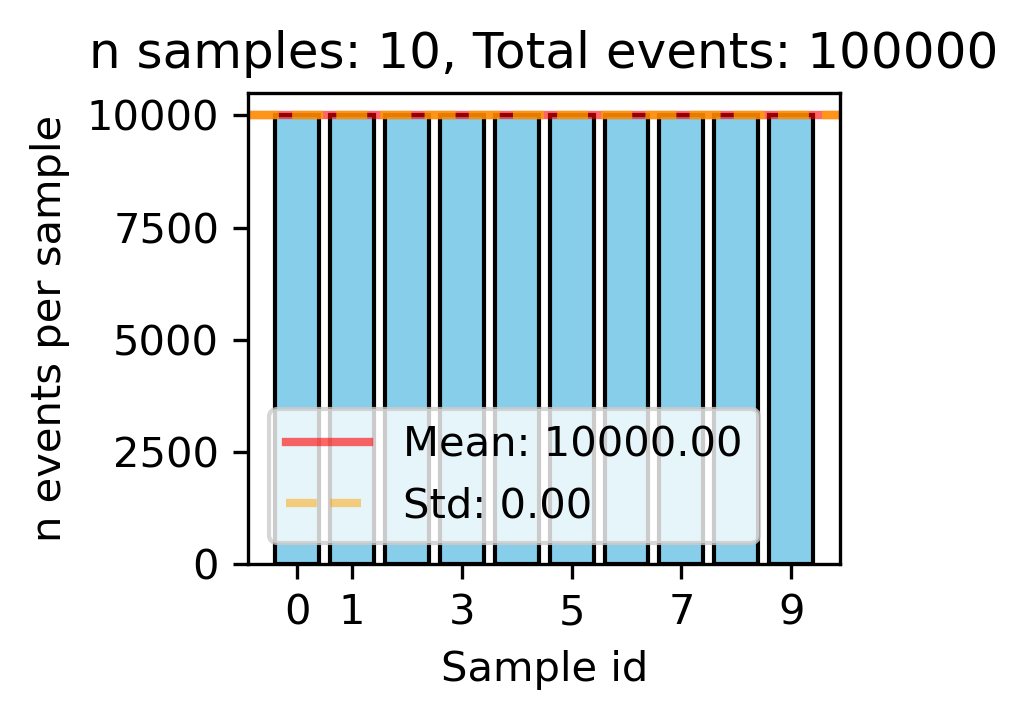

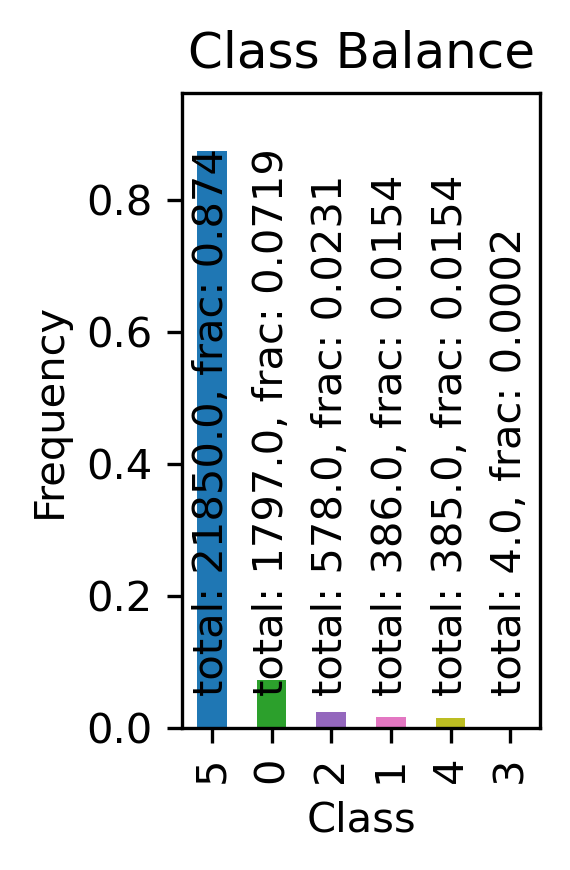

In [10]:

# Align channel names across samples, use 1st sample as reference
# Note: Harmonize channel names across samples by using the 1st file as reference for all others. Assume same channel order across samples.
fdm.align_channel_names(reference_channel_names=0)

# Check whether channel names were consistent across all samples
fdm.check_og_channel_names_df()

# Print the channel names
adata = fdm.anndata_list_[0]
print(f'# Channel names:\n{adata.var.index.tolist()}\n')

# Check the sample sizes
fdm.check_sample_sizes()
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)
fdm.plot_sample_size_df(sample_size_df=fdm.sample_sizes_, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Apply compensation
# Note: The Flowcyt consists of compensated non-transformed data samples in CSV format.
# If uncompensated data in FCS or LMD format is loaded set compensate = True.
compensate = False
if compensate:
    fdm.sample_wise_compensation()
    print(f'# Compensation log:\n{fdm.compensation_log_}')

# Apply preprocessing transformation, choose arcsinh with a cofactor of 150, save non-transformed data to layer 'raw'
fdm.sample_wise_preprocessing(flavour='arcsinh', save_raw_to_layer='raw', cofactor=150)

# Perform train test split
# Note: Typically, a randomized split at the sample level would be generated using:
# fdm.perform_data_split(data_split=(0.5, 0.5), filename_data_split='workflow_supervised_data_split.csv', random_state=42)
# For comparability with our notebook demonstrating the unsupervised workflow we use a manually defined split here.
split_df = pd.DataFrame({
    'filename': [f'Case_{i + 1}.csv' for i in range(len(data_filenames))],
    'mode': ['train'] * 5 + ['test'] * (len(data_filenames) - 5)
})
fdm.perform_data_split(data_split=split_df, filename_data_split='workflow_supervised_data_split.csv')

# Downsample the samples in the training set to 5000 events per sample. Set stratified=True to ensure preservation of class balances
# Note: Aggressive downsampling is done for faster MLP and SOM classifier training and faster UMAP and t-SNE computation. In practice more events per sample should be retained.
fdm.sample_wise_downsampling(data_set='train', target_num_events=5000, stratified=True, label_key='label', label_layer_key='raw');

# Check the class balance in the training set
class_balance_df = fdm.check_class_balance(data_set='train', label_key='label', label_layer_key='raw')
fig, ax = plt.subplots(figsize=(2, 3), dpi=300)
fdm.plot_class_balance_df(class_balance_df=class_balance_df, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)



### 4.) Classifier training
Train the MLP and  SOM classifier (supervised). A subset of channels is defined for model training. Here, a SOM grid size of $10\times10$ is used, for larger datasets $25\times 25$ is recommended to achieve good separation of populations.

In [11]:
# Extract concatenated and shuffled data matrix for model training
# Note: Generate a data Pytorch DataLoader with batch_size=-1 (meaning all events), and extract the 1st batch.
channels = [
    'FS INT', 'SS INT',
    'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO'
]
data_loader = fdm.get_data_loader(
    data_set='train',
    label_key='label',
    label_layer_key='raw',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train, y_train = next(iter(data_loader))

# Instantiate the MLP classifier
n_epochs = 200
mlp_clf = MLPClassifier(
    layer_sizes=(128, 64, 32),
    n_epochs=n_epochs,
    optimizer_params={'lr': 0.001},
    data_loader_params={'batch_size': 128, 'shuffle': True, 'num_workers': 1},
    validation_fraction=0.1,
    early_stopping=True,
    device='cuda:0' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Fit
mlp_clf.fit(X=x_train, y=y_train)

# Save
mlp_clf.save(filepath=SAVE_PATH, filename='workflow_supervised_mlp_classifier.pkl')

# Instantiate the SOM classifier
som_clf = SOMClassifier(
    som_topology='planar',
    som_grid_type='rectangular',
    som_dimensions=(10, 10),
    neighborhood='gaussian',
    gaussian_neighborhood_sigma=0.1,
    initialization='pca',
    n_epochs=100,
    radius_0=-0.5,
    radius_n=0.1,
    radius_cooling='exponential',
    learning_rate_0=0.1,
    learning_rate_n=0.001,
    learning_rate_decay='exponential',
    unlabeled_label=-999,
    verbosity=1
)

# Fit
som_clf.fit(X=x_train, y=y_train)

# Save
som_clf.save(filepath=SAVE_PATH, filename='workflow_supervised_som_classifier.pkl')


    100% [===================================================]


Time for epoch 1: 0.1466 Time for epoch 2: 0.0839 Time for epoch 3: 0.05961 Time for epoch 4: 0.04205 Time for epoch 5: 0.03017 Time for epoch 6: 0.02917 Time for epoch 7: 0.02972 Time for epoch 8: 0.02076 Time for epoch 9: 0.02085 Time for epoch 10: 0.02217 Time for epoch 11: 0.02868 Time for epoch 12: 0.02355 Time for epoch 13: 0.02367 Time for epoch 14: 0.01993 Time for epoch 15: 0.01912 Time for epoch 16: 0.01906 Time for epoch 17: 0.0168 Time for epoch 18: 0.02087 Time for epoch 19: 0.01902 Time for epoch 20: 0.02036 Time for epoch 21: 0.01837 Time for epoch 22: 0.01759 Time for epoch 23: 0.02114 Time for epoch 24: 0.01743 Time for epoch 25: 0.01965 Time for epoch 26: 0.01843 Time for epoch 27: 0.0194 Time for epoch 28: 0.01832 Time for epoch 29: 0.01875 Time for epoch 30: 0.01941 Time for epoch 31: 0.02231 Time for epoch 32: 0.02297 Time for epoch 33: 0.01834 Time for epoch 34: 0.01962 Time for epoch 35: 0.01997 Time for epoch 36: 0.02046 Time for epoch 37: 0.0174 Time for epoch 

In [12]:
y_preds_mlp = []
y_preds_som = []
for adata in fdm.test_data_:
    x = adata[:, channels].X.copy()
    y_preds_mlp.append(mlp_clf.predict(x))
    y_preds_som.append(som_clf.predict(x))


### 5.) Export

In [13]:

# Export
export_to_fcs(
    data_list=fdm.test_data_,
    layer_key='raw',  # Compensated but untransformed data
    sample_wise=False,
    add_columns=[y_preds_mlp, y_preds_som],
    add_columns_names=['pred_mlp', 'pred_som'],
    scale_columns=['pred_mlp', 'pred_som'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames='workflow_supervised_export.fcs'
)


### 6.) Feedback loop [optional]

To check the quality of the "ground truth" training labels, perform unsupervised dimensionality reduction (SOM, UMAP, t-SNE) on the training data and export the results to FCS (compare unsupervised workflow).

In [14]:
# Extract data matrices (arcsinh transformed and non-transformed) without shuffling and keep track of sample IDs
data_matrices = []
data_matrices_raw = []
y_trues = []
for i, adata in enumerate(fdm.train_data_):
    data_matrices.append(adata[:, channels].X.copy())
    data_matrices_raw.append(adata[:, channels].layers['raw'].copy())
    y_trues.append(get_labels(adata=adata, label_key='label', layer_key='raw', verbosity=0))
x_ordered = np.concatenate(data_matrices, axis=0)
x_ordered_raw = np.concatenate(data_matrices_raw, axis=0)
y_true = np.concatenate(y_trues, axis=0)

# Compute dimensionality reductions
_, x_som, _, _ = som_clf.transform(x_ordered)

reducer_umap = UMAP(n_components=2, n_jobs=-1)
x_umap = reducer_umap.fit_transform(x_ordered)

reducer_tsne = TSNE(n_components=2, n_jobs=-1)
x_tsne = reducer_tsne.fit_transform(x_ordered)

# Transform into correct format for export
x_som0s = []
x_som1s = []
x_umap0s = []
x_umap1s = []
x_tsne0s = []
x_tsne1s = []
starting_idx = 0
for x in data_matrices:
    n_events = x.shape[0]
    x_som_current = x_som[starting_idx:starting_idx + n_events]
    x_umap_current = x_umap[starting_idx:starting_idx + n_events]
    x_tsne_current = x_tsne[starting_idx:starting_idx + n_events]
    x_som0s.append(x_som_current[:, 0])
    x_som1s.append(x_som_current[:, 1])
    x_umap0s.append(x_umap_current[:, 0])
    x_umap1s.append(x_umap_current[:, 1])
    x_tsne0s.append(x_tsne_current[:, 0])
    x_tsne1s.append(x_tsne_current[:, 1])
    starting_idx += n_events

# Export
export_to_fcs(
    data_list=fdm.train_data_,
    layer_key='raw',
    sample_wise=False,
    add_columns=[
        y_trues,
        x_som0s, x_som1s,
        x_umap0s, x_umap1s,
        x_tsne0s, x_tsne1s,
    ],
    add_columns_names=['Blast', 'SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2'],
    scale_columns=['Blast', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames='workflow_supervised_export_feedback.fcs',
)

### 6.) Feedback loop [optional] cont.

The labels of training data can be validated and refined by jointly analyzing the learned 2D data representations and conventional marker-marker scatter plots using conventional FCM analysis software. We illustrate this expert-in-the-loop calibration of ground truth labels with the following:

Training data is visualized in (**A**) SOM, (**B**) UMAP, and (**C**) t-SNE representation space. Conventional marker-marker scatter plots for B cell gating are shown in (**D**-**F**).

**Note:** Some of the SOM nodes in which B cells (orange) constitute the majority also contain cells of the *others* class (gray). This may hint at inconsistencies in the ground truth labels.

To investigate, one can define a gate encompassing SOM nodes enriched in B cells, including events not originally labeled as such. These events can then be examined in conventional marker-marker plots to assess whether their expression profiles are consistent with a B cell phenotype. The UMAP and t-SNE representations can be used similarly. If combined analysis of 2D representations and marker-marker plots indeed reveals inaccurate ground truth labels, this can now be corrected.

The same approach can be applied to the other labeled subpopulations as well. Subsequent retraining of classifiers with refined ground truth labels is expected to improve automated gating results.

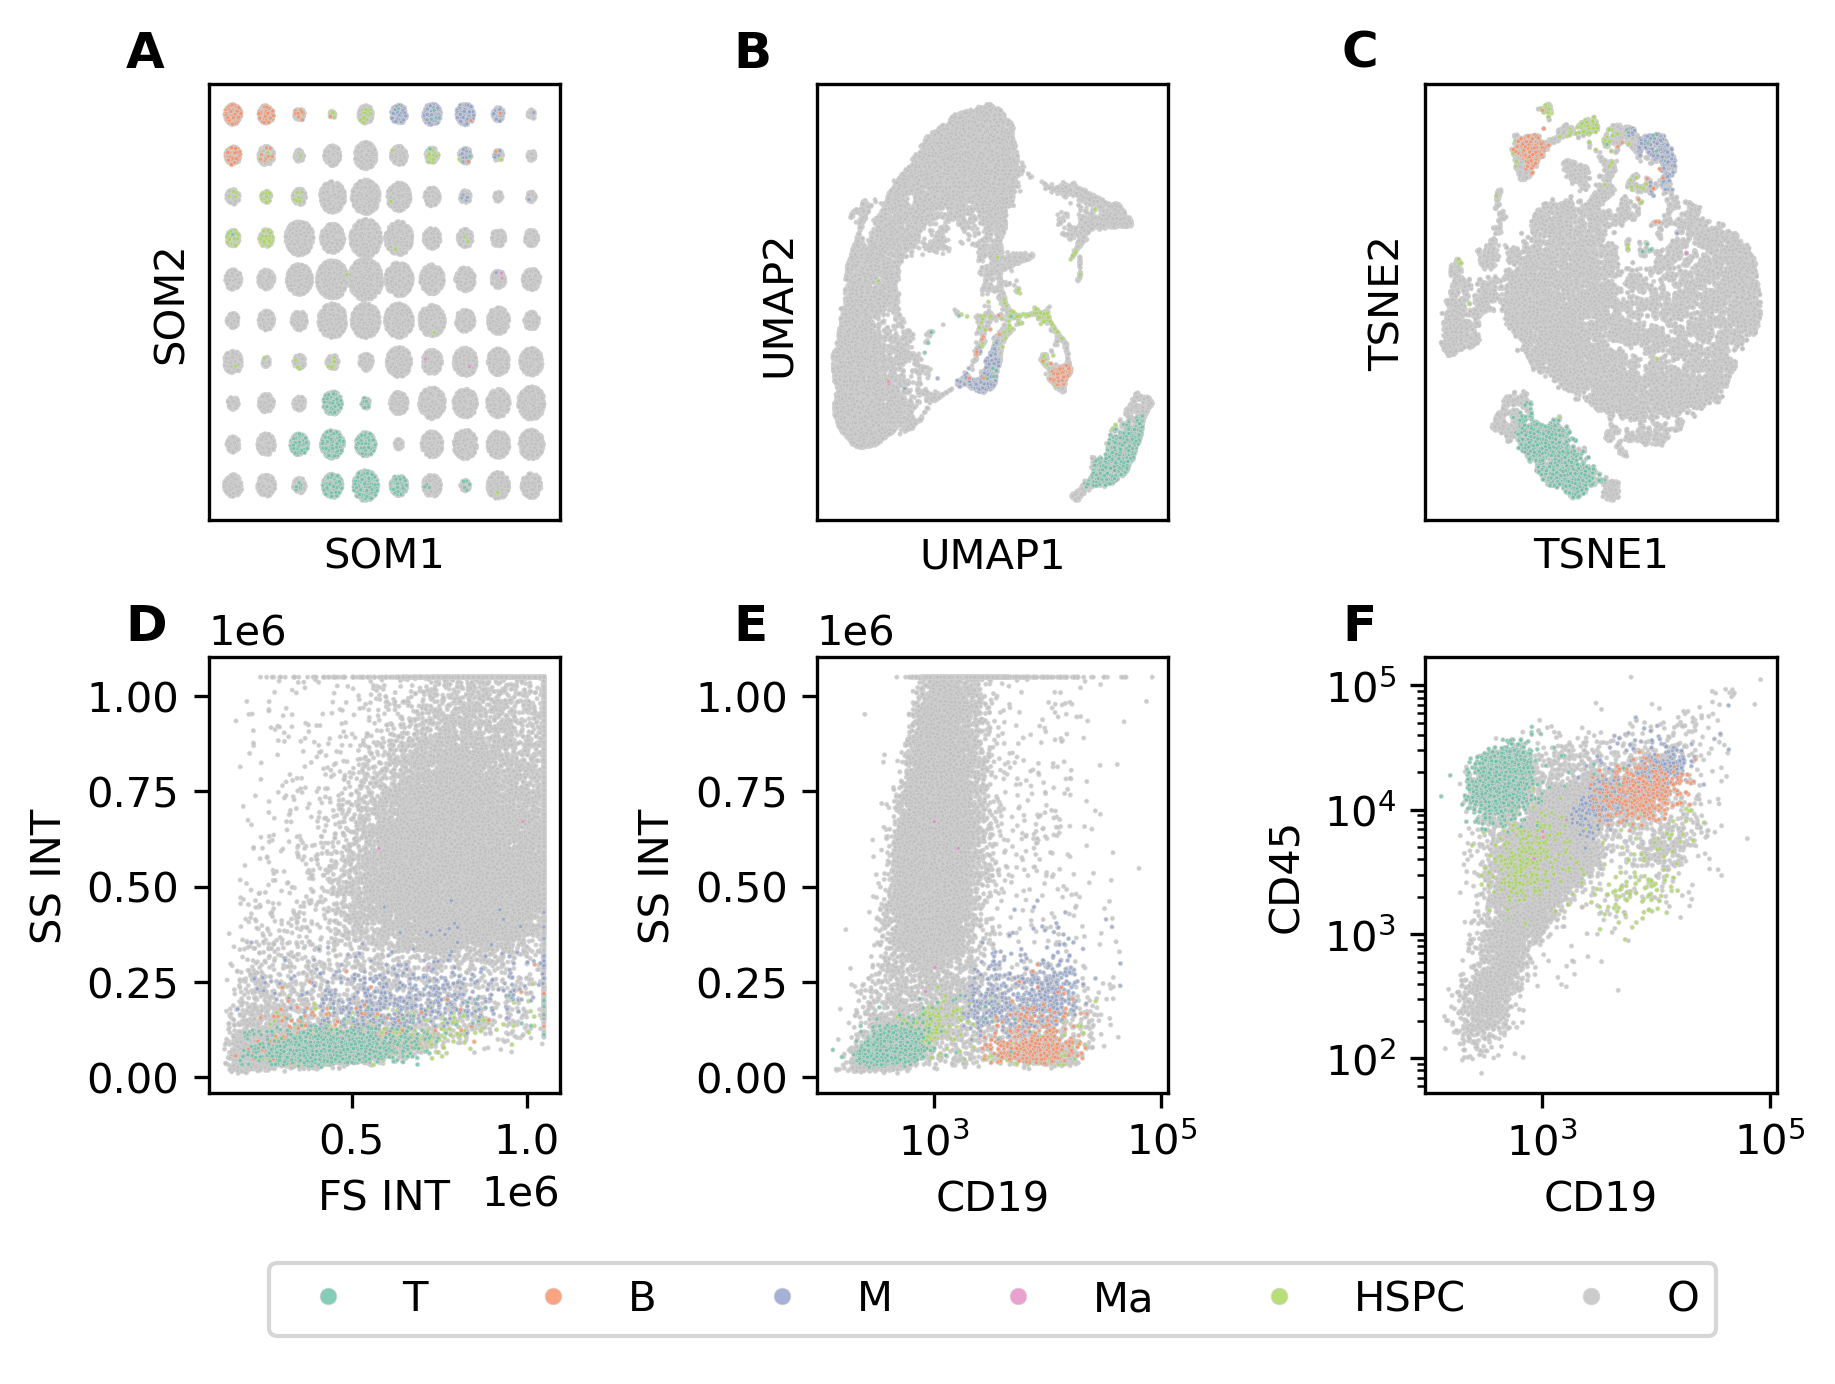

In [15]:
# Create df for plotting
plot_dfs = []
for adata in fdm.train_data_:
    df = pd.DataFrame(adata.layers['raw'], columns=adata.var.index)
    fn = adata.uns['filename']
    match = re.search(r'Case_(\d{1,2})\.csv$', fn)
    df['fn'] = fn
    df['sample_id'] = int(match.group(1))
    plot_dfs.append(df)

plot_df = pd.concat(plot_dfs, axis=0, ignore_index=True)

for dimred, x in zip(['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):
    for i in range(2):
        plot_df[f'{dimred}_{i + 1}'] = x[:, i]

int_label_to_cell_type = {
        0: 'T',  # T lymphocyte
        1: 'B',  # B lymphocyte
        2: 'M',  # Monocyte
        3: 'Ma',  # Mast cell
        4: 'HSPC',  # Hematopoietic stem and progenitor cell
        5: 'O'  # Others
}
plot_df['cell_type'] = plot_df['label'].map(int_label_to_cell_type)

# Define palette
unique_cell_types = ['T', 'B', 'M', 'Ma', 'HSPC', 'O']
palette = {val: col for val, col in zip(unique_cell_types, sns.color_palette('Set2'))}
palette['O'] = (0.75, 0.75, 0.75)

plot_df = plot_df.sort_values(
    by='cell_type',
    key=lambda s: s.map({v: i for i, v in enumerate(unique_cell_types[::-1])}),
)

fig, axd = plt.subplot_mosaic(
    [
        list('ABC'),
        list('DEF'),
        ['L'] * 3,
    ],
    figsize=(6, 4.5),
    gridspec_kw={'height_ratios': [2/4.5, 2/4.5, 0.5/4.5]},
    dpi=300,
    constrained_layout=True,
)

marker_size = 1.0

for key, name, x in zip(list('ABC'), ['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):

    ax = axd[key]
    sns.scatterplot(
        data=plot_df,
        x=f'{name}_1',
        y=f'{name}_2',
        hue='cell_type',
        hue_order=unique_cell_types,
        palette=palette,
        s=marker_size,
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
        ax=ax
    )

    ax.set_xlabel(f'{name}1')
    ax.set_ylabel(f'{name}2')
    ax.set_xticks([])
    ax.set_yticks([])

# 'CD14', 'CD19', 'CD13', 'CD33', 'CD34', 'CD117', 'CD7', 'CD16', 'HLA', 'CD45'
marker_combinations = [('FS INT', 'SS INT'), ('FL2 INT_CD19-PE', 'SS INT'), ('FL2 INT_CD19-PE', 'FL10 INT_CD45-KO')]
marker_to_shorthand = {'FL2 INT_CD19-PE': 'CD19', 'FL10 INT_CD45-KO': 'CD45'}

for key, (marker0, marker1) in zip(list('DEF'), marker_combinations):

    ax = axd[key]
    sns.scatterplot(
        data=plot_df,
        x=marker0,
        y=marker1,
        hue='cell_type',
        hue_order=unique_cell_types,
        palette=palette,
        s=marker_size,
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
        ax=ax
    )

    ax.set_xlabel(marker_to_shorthand.get(marker0, marker0))
    ax.set_ylabel(marker_to_shorthand.get(marker1, marker1))

    if marker0 not in ['FS INT', 'SS INT']:
        ax.set_xscale('log')
    if marker1 not in ['FS INT', 'SS INT']:
        ax.set_yscale('log')
    ax.grid(False)

handles, labels = axd['A'].get_legend_handles_labels()
axd['L'].legend(handles, labels, loc='center', markerscale=4.0, ncol=len(handles))
axd['L'].axis('off')
for key in list('ABCDEF'):
    axd[key].get_legend().remove()

for label, ax in axd.items():
    if label != 'L':
        trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
        ax.text(0.0, 0.95, label, transform=ax.transAxes + trans, fontsize=12, va='bottom', fontfamily='sans-serif', fontweight='bold')

plt.show()

### Plot losses from MLP training [optional]
This is not part of the main workflow. We visualize training and validation loss and check in which epoch early stopping was triggered.

# Number of events in training set: 22500, Number of events in validation set: 2500
# Early stopping was triggered at epoch 24


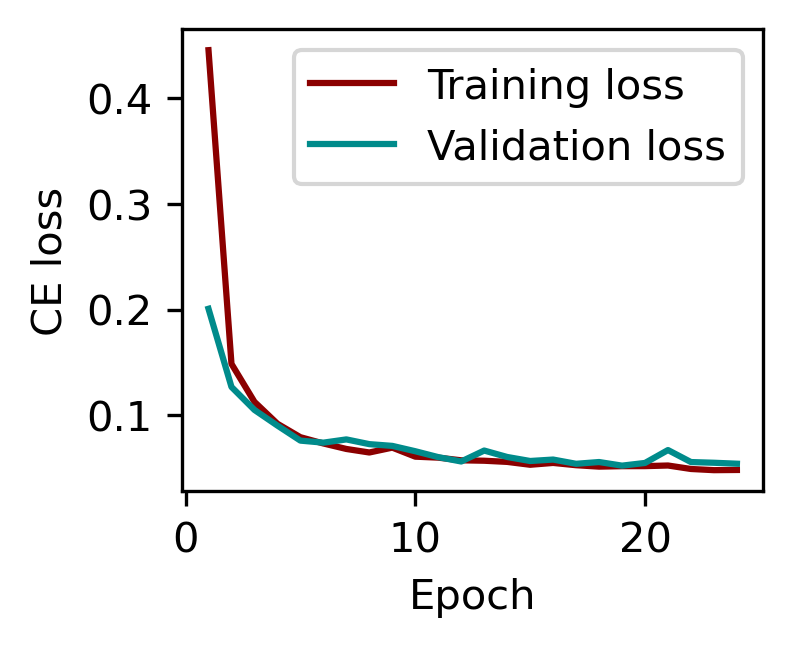

In [16]:
# Plot losses from MLP training
tl = mlp_clf.training_log_
print(f'# Number of events in training set: {tl.pop('num_events_train')}, Number of events in validation set: {tl.pop('num_events_val')}')
loss_df = pd.DataFrame(tl)
n_epochs_trained = loss_df.shape[0]
if n_epochs_trained < n_epochs:
    print(f'# Early stopping was triggered at epoch {n_epochs_trained}')
x_vals = np.array(list(range(1, n_epochs_trained + 1)))
fig, ax = plt.subplots(figsize=(2.5, 2.0), dpi=300)
ax.plot(
    x_vals, loss_df['training_loss'].to_numpy(),
    color='darkred',
    label='Training loss'
)
ax.plot(
    x_vals, loss_df['validation_loss'].to_numpy(),
    color='darkcyan',
    label='Validation loss'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('CE loss')
ax.legend()
plt.show()
plt.close(fig)

### Performance evaluation [optional]

This is not part of the main workflow. Since in this example test samples are annotated with ground truth labels as well, we can compute performance metrics to evaluate classifier performance.

# Prediction performance:
   sample_ID  sample_name method  precision    recall        f1
0          0  Case_10.csv    mlp   0.769758  0.694989  0.713860
2          1   Case_6.csv    mlp   0.713992  0.671213  0.685220
4          2   Case_7.csv    mlp   0.933076  0.749380  0.783025
6          3   Case_8.csv    mlp   0.757052  0.723519  0.737937
8          4   Case_9.csv    mlp   0.679639  0.635871  0.647519
1          0  Case_10.csv    som   0.668165  0.611476  0.625108
3          1   Case_6.csv    som   0.605507  0.744072  0.639007
5          2   Case_7.csv    som   0.840758  0.844156  0.836454
7          3   Case_8.csv    som   0.664571  0.644712  0.650710
9          4   Case_9.csv    som   0.631299  0.570208  0.586620


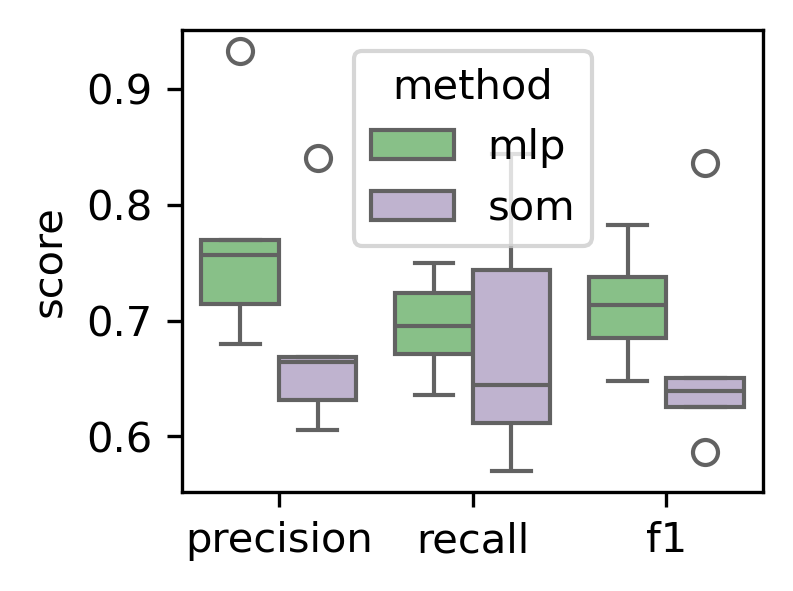

In [17]:
method_to_clf = {'mlp': mlp_clf, 'som': som_clf}
rows = []
for i, adata in enumerate(fdm.test_data_):

    sample_name = adata.uns['filename']
    x = adata[:, channels].X.copy()
    y_true = get_labels(adata=adata, label_key='label', layer_key='raw', verbosity=0)

    for method in ['mlp', 'som']:

        y_pred = method_to_clf[method].predict(x)

        precision = precision_score(y_true, y_pred, average='macro', zero_division=0.0)
        recall = recall_score(y_true, y_pred, average='macro', zero_division=0.0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0.0)

        rows.append({
            'sample_ID': i,
            'sample_name': sample_name,
            'method': method,
            'precision': precision,
            'recall': recall,
            'f1': f1,
        })

res_df = pd.DataFrame(rows).sort_values(by=['method'])

print(f'# Prediction performance:\n{res_df}')

plot_df = res_df.melt(
    id_vars=['sample_ID', 'sample_name', 'method'],
    value_vars=['precision', 'recall', 'f1'],
    var_name='metric',
    value_name='score'
)

fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)
sns.boxplot(
    data=plot_df,
    x='metric',
    y='score',
    hue='method',
    palette='Accent',
    ax=ax,
)
ax.set_xlabel(None)
plt.show()
